# Working with RDF and SPARQL for Knowledge Graph Queries

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand RDF (Resource Description Framework) structure and syntax
- Learn how to create and represent knowledge graphs using RDF
- Master SPARQL query language for querying knowledge graphs
- Apply RDF/SPARQL to real-world knowledge representation problems

## 🔗 Where this fits

**Builds on:** Unit 2, lesson 02 "Expert Systems" — rules over facts; RDF stores those facts as a queryable graph instead.

**Used later in:** Course 07 (AIAT 121) — Unit 3, where extracting entities and relations from text is what fills a graph like this.

---

This notebook covers the practical activity from **Course 01, Unit 2**:
- **Activity:** Working with RDF and SPARQL for knowledge graph queries

---

## Introduction to RDF and Knowledge Graphs

RDF (Resource Description Framework) is a standard model for data interchange on the Web. It represents information as a graph structure where:
- **Resources** are nodes (entities)
- **Properties** are edges (relationships)
- **Statements** are triples (Subject-Predicate-Object)


## 🎯 "Things, not strings"

On **16 May 2012** Google announced the **Knowledge Graph** under that slogan. Up
to that point a search for *Taj Mahal* was a match on a sequence of characters,
and the engine had no way to know whether you meant the monument, the musician or
the casino in Atlantic City — the three readings Google's own announcement used. The Knowledge Graph replaced the string with an
**entity** that has typed relations to other entities — *is a* building, *located
in* Agra, *completed* 1653 — which is what let a search box start answering
questions instead of returning links.

Five months later, on **29 October 2012**, the Wikimedia Foundation launched
**Wikidata**, the same idea run in the open: a freely licensed, community-edited
store of entities and relations that now supplies the structured facts behind
Wikipedia's infoboxes across every language edition. Both are, underneath,
collections of **triples** — subject, predicate, object — which is exactly what
you are about to build with `rdflib` in the next cell.

### What goes wrong without a graph

Put the same knowledge in a relational table and every new *kind* of relationship
needs a schema change: a column, a join table, a migration. Facts about courses,
instructors, prerequisites, rooms and accreditation each want their own shape. A
triple store has one shape for everything, so adding a relationship you did not
anticipate costs one row, not one migration — which is why this format is used
for knowledge that grows in unpredictable directions. That flexibility has a
price, and the limits section at the end of this notebook is that price.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Install required libraries if not already installed
# !pip install rdflib sparqlwrapper

import rdflib
from rdflib import Graph, Namespace, URIRef, Literal, BNode
from rdflib.namespace import RDF, RDFS, FOAF, XSD
from SPARQLWrapper import SPARQLWrapper, JSON
import json

print("✅ Libraries imported successfully!")
print("RDFLib version:", rdflib.__version__)


✅ Libraries imported successfully!
RDFLib version: 7.6.0


## Part 1: Creating an RDF Knowledge Graph

Let's create a simple knowledge graph about university courses and instructors.


In [2]:
# Create a new RDF graph
g = Graph()

# Define custom namespaces
UNI = Namespace("http://example.org/university/")
PERSON = Namespace("http://example.org/person/")

# Bind namespaces for cleaner output
g.bind("uni", UNI)
g.bind("person", PERSON)
g.bind("foaf", FOAF)

print("✅ RDF Graph created with namespaces defined")


✅ RDF Graph created with namespaces defined


In [3]:
# Add triples to the graph
# Format: (Subject, Predicate, Object)

# Course: AIAT 111
g.add((UNI.AIAT111, RDF.type, UNI.Course))
g.add((UNI.AIAT111, RDFS.label, Literal("Introduction to AI & Applications")))
g.add((UNI.AIAT111, UNI.courseCode, Literal("AIAT 111", datatype=XSD.string)))
g.add((UNI.AIAT111, UNI.creditHours, Literal(3, datatype=XSD.integer)))

# Course: AIAT 112
g.add((UNI.AIAT112, RDF.type, UNI.Course))
g.add((UNI.AIAT112, RDFS.label, Literal("Python for AI")))
g.add((UNI.AIAT112, UNI.courseCode, Literal("AIAT 112", datatype=XSD.string)))
g.add((UNI.AIAT112, UNI.creditHours, Literal(3, datatype=XSD.integer)))

# Instructor: Dr. Smith
g.add((PERSON.DrSmith, RDF.type, FOAF.Person))
g.add((PERSON.DrSmith, FOAF.name, Literal("Dr. John Smith")))
g.add((PERSON.DrSmith, UNI.teaches, UNI.AIAT111))
# Instructor: Dr. Ali
g.add((PERSON.DrAli, RDF.type, FOAF.Person))
g.add((PERSON.DrAli, FOAF.name, Literal("Dr. Ahmed Ali")))
g.add((PERSON.DrAli, UNI.teaches, UNI.AIAT112))
# Relationships: Course prerequisites
g.add((UNI.AIAT112, UNI.hasPrerequisite, UNI.AIAT111))
print(f"✅ Added {len(g)} triples to the knowledge graph")
print(f"Graph contains {len(set(g.subjects()))} unique subjects")


✅ Added 15 triples to the knowledge graph
Graph contains 4 unique subjects


## Part 2: Visualizing and Inspecting the RDF Graph

Let's examine what we've created:


In [4]:
# Walk the graph triple by triple: every fact in RDF is a (subject, predicate, object)
# statement — seeing the raw triples demystifies what a 'knowledge graph' actually stores.
# Display all triples in the graph
print("=" * 60)
print("All Triples in the Knowledge Graph:")
print("=" * 60)
for s, p, o in g:
 print(f"Subject: {s}")
 print(f" Predicate: {p}")
 print(f" Object: {o}")
 print()

All Triples in the Knowledge Graph:
Subject: http://example.org/university/AIAT111
 Predicate: http://www.w3.org/2000/01/rdf-schema#label
 Object: Introduction to AI & Applications

Subject: http://example.org/university/AIAT111
 Predicate: http://www.w3.org/1999/02/22-rdf-syntax-ns#type
 Object: http://example.org/university/Course

Subject: http://example.org/person/DrSmith
 Predicate: http://example.org/university/teaches
 Object: http://example.org/university/AIAT111

Subject: http://example.org/university/AIAT112
 Predicate: http://www.w3.org/1999/02/22-rdf-syntax-ns#type
 Object: http://example.org/university/Course

Subject: http://example.org/person/DrSmith
 Predicate: http://www.w3.org/1999/02/22-rdf-syntax-ns#type
 Object: http://xmlns.com/foaf/0.1/Person

Subject: http://example.org/person/DrAli
 Predicate: http://www.w3.org/1999/02/22-rdf-syntax-ns#type
 Object: http://xmlns.com/foaf/0.1/Person

Subject: http://example.org/university/AIAT112
 Predicate: http://example.org/u

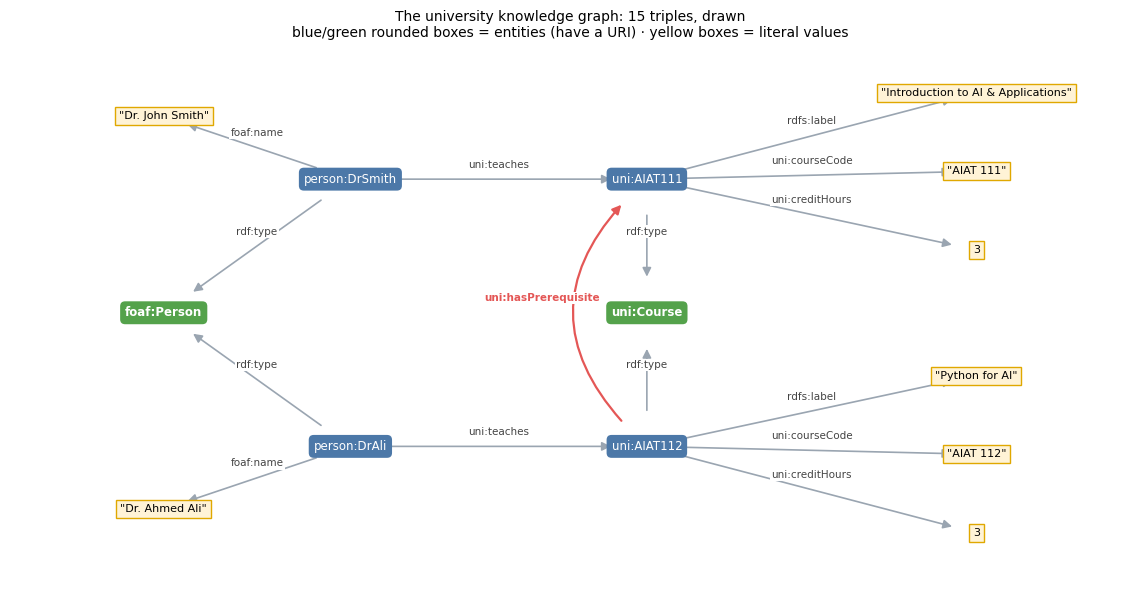

Triples in the graph : 15
Triples drawn        : 15
Triples not drawn    : 0 
Distinct subjects    : 4


In [5]:
# 📊 FIGURE — the same 15 triples, drawn as the graph they actually are.
# WHAT: nothing new is computed here. We walk the SAME rdflib graph `g` printed above
#       and draw one arrow per triple: tail = subject, head = object, arrow label =
#       predicate. Rounded boxes are entities (things with a URI); yellow boxes are literals
#       (raw values). WHY: "knowledge graph" is a claim about shape, and a printed list
#       of triples hides the shape completely.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from rdflib import Literal


def short(term):
    """Turn a URI into its readable qname (uni:AIAT111); leave literals as their value."""
    if isinstance(term, Literal):
        return str(term)
    try:
        return g.qname(term)
    except Exception:
        return str(term)


# Deterministic hand-set layout: entities on the left/middle, literal values on the outside.
ENTITY_POS = {
    'foaf:Person':    (-4.4,  0.0),
    'person:DrSmith': (-2.7,  1.7),
    'person:DrAli':   (-2.7, -1.7),
    'uni:AIAT111':    ( 0.0,  1.7),
    'uni:AIAT112':    ( 0.0, -1.7),
    'uni:Course':     ( 0.0,  0.0),
}
LITERAL_POS = {
    ('uni:AIAT111', 'rdfs:label'):      ( 3.0,  2.8),
    ('uni:AIAT111', 'uni:courseCode'):  ( 3.0,  1.8),
    ('uni:AIAT111', 'uni:creditHours'): ( 3.0,  0.8),
    ('uni:AIAT112', 'rdfs:label'):      ( 3.0, -0.8),
    ('uni:AIAT112', 'uni:courseCode'):  ( 3.0, -1.8),
    ('uni:AIAT112', 'uni:creditHours'): ( 3.0, -2.8),
    ('person:DrSmith', 'foaf:name'):    (-4.4,  2.5),
    ('person:DrAli', 'foaf:name'):      (-4.4, -2.5),
}

fig, ax = plt.subplots(figsize=(11.5, 6.0))
unplaced = []
for s, p, o in sorted(g, key=lambda t: (str(t[0]), str(t[1]))):
    ss, ps, os_ = short(s), short(p), short(o)
    p1 = ENTITY_POS.get(ss)
    p2 = ENTITY_POS.get(os_) if not isinstance(o, Literal) else LITERAL_POS.get((ss, ps))
    if p1 is None or p2 is None:
        unplaced.append((ss, ps, os_))
        continue
    # Course-to-course edges are bowed out to the left so they do not run through
    # the uni:Course node that sits between them.
    rad = -0.55 if ps == 'uni:hasPrerequisite' else 0.0
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle='-|>', mutation_scale=13,
                                 color="#E45756" if rad else "#9AA5B1",
                                 lw=1.6 if rad else 1.2,
                                 connectionstyle=f"arc3,rad={rad}",
                                 shrinkA=26, shrinkB=18 if isinstance(o, Literal) else 26,
                                 zorder=1))
    mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    if rad:
        mx, my = mx - 0.95, my   # follow the bow, not the straight line
    ax.text(mx, my + 0.12, ps, fontsize=7.5, ha="center", va="bottom",
            color="#E45756" if rad else "#444", fontweight="bold" if rad else "normal",
            bbox=dict(fc="white", ec="none", pad=0.8), zorder=3)
    if isinstance(o, Literal):   # draw the literal leaf as a square box
        ax.text(p2[0], p2[1], f'"{os_}"' if not os_.isdigit() else os_,
                fontsize=8, ha="center", va="center", zorder=4,
                bbox=dict(boxstyle="square,pad=0.35", fc="#FFF3D6", ec="#E0A800"))

for name, (x, y) in ENTITY_POS.items():
    is_class = name in ('foaf:Person', 'uni:Course')
    ax.text(x, y, name, fontsize=8.5, ha="center", va="center", zorder=4,
            fontweight="bold" if is_class else "normal", color="white",
            bbox=dict(boxstyle="round,pad=0.42",
                      fc="#54A24B" if is_class else "#4C78A8", ec="none"))

ax.set_xlim(-5.8, 4.4); ax.set_ylim(-3.4, 3.4); ax.set_axis_off()
ax.set_title(f"The university knowledge graph: {len(g)} triples, drawn\n"
             "blue/green rounded boxes = entities (have a URI) · yellow boxes = literal values",
             fontsize=10)
plt.tight_layout()
plt.show()

print(f"Triples in the graph : {len(g)}")
print(f"Triples drawn        : {len(g) - len(unplaced)}")
print(f"Triples not drawn    : {len(unplaced)} {unplaced if unplaced else ''}")
print(f"Distinct subjects    : {len(set(g.subjects()))}")

### 👁️ Read the figure

Every arrow is one line of the printout above. Follow three of them and the whole
model is in your hands.

- **`person:DrSmith --uni:teaches--> uni:AIAT111`** — an arrow between two blue
  entities. This is the join that SPARQL Query 2 walks; in a relational database
  it would be a foreign key and a table.
- **`uni:AIAT112 --uni:hasPrerequisite--> uni:AIAT111`** — an arrow from a course
  to *another course*. Same-type relationships are exactly what tables handle
  badly and graphs handle for free; this single edge is the whole answer to
  Query 3.
- **`uni:AIAT111 --rdfs:label--> "Introduction to AI & Applications"`** — an arrow
  into a **yellow box**. Literals are where the graph ends: values have no
  outgoing arrows, so you can never traverse *through* one.

**What this proves — "things, not strings".** The two green nodes (`uni:Course`,
`foaf:Person`) are the only type declarations in the graph, and every blue node
reaches one of them by a single `rdf:type` arrow. Nothing here is a table, and
adding a new *kind* of fact — a room, an accreditation, a semester — means adding
one more arrow, never a schema migration. That is the property the case study at
the top of this notebook is describing.

**And the honest limit, visible in the same picture:** `uni:AIAT111` has **no**
outgoing `hasPrerequisite` arrow. The drawing cannot tell you whether that means
"has no prerequisite" or "nobody entered one" — which is Discuss question 1,
staring at you from the page.

In [6]:
# Serialize the graph in different formats
print("=" * 60)
print("RDF/XML Format:")
print("=" * 60)
xml_output = g.serialize(format='xml')
if isinstance(xml_output, bytes):
    xml_output = xml_output.decode('utf-8')
print(xml_output)

RDF/XML Format:
<?xml version="1.0" encoding="utf-8"?>
<rdf:RDF
   xmlns:foaf="http://xmlns.com/foaf/0.1/"
   xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
   xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
   xmlns:uni="http://example.org/university/"
>
  <rdf:Description rdf:about="http://example.org/university/AIAT111">
    <rdf:type rdf:resource="http://example.org/university/Course"/>
    <rdfs:label>Introduction to AI &amp; Applications</rdfs:label>
    <uni:courseCode rdf:datatype="http://www.w3.org/2001/XMLSchema#string">AIAT 111</uni:courseCode>
    <uni:creditHours rdf:datatype="http://www.w3.org/2001/XMLSchema#integer">3</uni:creditHours>
  </rdf:Description>
  <rdf:Description rdf:about="http://example.org/person/DrSmith">
    <rdf:type rdf:resource="http://xmlns.com/foaf/0.1/Person"/>
    <foaf:name>Dr. John Smith</foaf:name>
    <uni:teaches rdf:resource="http://example.org/university/AIAT111"/>
  </rdf:Description>
  <rdf:Description rdf:about="http://exampl

In [7]:
# Serialization: the same graph written out in Turtle syntax, the human-readable RDF
# format you will meet in real datasets and documentation.
# Serialize in Turtle format (more readable)
print("=" * 60)
print("Turtle Format (TTL):")
print("=" * 60)
# Serialize in Turtle format (more readable)
print("=" * 60)
print("Turtle Format (TTL):")
print("=" * 60)
turtle_output = g.serialize(format='turtle')
if isinstance(turtle_output, bytes):
    turtle_output = turtle_output.decode('utf-8')
print(turtle_output)

Turtle Format (TTL):
Turtle Format (TTL):
@prefix foaf: <http://xmlns.com/foaf/0.1/> .
@prefix person: <http://example.org/person/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix uni: <http://example.org/university/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

person:DrAli a foaf:Person ;
    uni:teaches uni:AIAT112 ;
    foaf:name "Dr. Ahmed Ali" .

person:DrSmith a foaf:Person ;
    uni:teaches uni:AIAT111 ;
    foaf:name "Dr. John Smith" .

uni:AIAT112 a uni:Course ;
    rdfs:label "Python for AI" ;
    uni:courseCode "AIAT 112"^^xsd:string ;
    uni:creditHours 3 ;
    uni:hasPrerequisite uni:AIAT111 .

uni:AIAT111 a uni:Course ;
    rdfs:label "Introduction to AI & Applications" ;
    uni:courseCode "AIAT 111"^^xsd:string ;
    uni:creditHours 3 .




## Part 3: Querying with SPARQL

SPARQL (SPARQL Protocol and RDF Query Language) is the standard query language for RDF graphs.


In [8]:
# First SPARQL query: pattern-match over triples. Variables start with '?', and the
# WHERE block describes the shape of the facts we want back.
# SPARQL Query 1: Find all courses
query1 = """
PREFIX uni: <http://example.org/university/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?course ?name
WHERE {
 ?course rdf:type uni:Course .
 ?course rdfs:label ?name .
}
"""

print("Query 1: Find all courses")
print("=" * 60)
# Execute the query against the graph and iterate over the matched rows.
results = g.query(query1)
for row in results:
 print(f"Course: {row.course}")
 print(f" Name: {row.name}")
 print()

Query 1: Find all courses
Course: http://example.org/university/AIAT111
 Name: Introduction to AI & Applications

Course: http://example.org/university/AIAT112
 Name: Python for AI



In [9]:
# A JOIN in SPARQL: chaining several triple patterns on shared variables links a person
# to the course they teach — the graph equivalent of joining two tables.
# SPARQL Query 2: Find all instructors and the courses they teach
query2 = """
PREFIX uni: <http://example.org/university/>
PREFIX person: <http://example.org/person/>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?instructor ?name ?course ?courseName
WHERE {
 ?instructor rdf:type foaf:Person .
 ?instructor foaf:name ?name .
 ?instructor uni:teaches ?course .
 ?course rdfs:label ?courseName .
}
"""

print("Query 2: Find instructors and their courses")
print("=" * 60)
# Each result row binds all four variables of the pattern at once.
results = g.query(query2)
for row in results:
 print(f"Instructor: {row.name}")
 print(f" Teaches: {row.courseName}")
 print()

Query 2: Find instructors and their courses
Instructor: Dr. John Smith
 Teaches: Introduction to AI & Applications

Instructor: Dr. Ahmed Ali
 Teaches: Python for AI



In [10]:
# Querying relationships between entities of the SAME type: which courses require which
# other courses — exactly the kind of question knowledge graphs answer well.
# SPARQL Query 3: Find courses with prerequisites
query3 = """
PREFIX uni: <http://example.org/university/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?course ?courseName ?prerequisite ?prereqName
WHERE {
 ?course uni:hasPrerequisite ?prerequisite .
 ?course rdfs:label ?courseName .
 ?prerequisite rdfs:label ?prereqName .
}
"""

print("Query 3: Find course prerequisites")
print("=" * 60)
# Run the pattern and print each course with its prerequisite.
results = g.query(query3)
for row in results:
 print(f"Course: {row.courseName}")
 print(f" Requires: {row.prereqName}")
 print()

Query 3: Find course prerequisites
Course: Python for AI
 Requires: Introduction to AI & Applications



## Part 4: Real-World Example - Knowledge Graph for AI Research

Let's create a more complex knowledge graph about AI research areas and publications.


In [11]:
# Create a new graph for AI research knowledge
research_g = Graph()

# Define namespaces
AI = Namespace("http://example.org/ai/")
RESEARCH = Namespace("http://example.org/research/")

research_g.bind("ai", AI)
research_g.bind("research", RESEARCH)

# Add research areas
research_g.add((AI.MachineLearning, RDF.type, AI.ResearchArea))
research_g.add((AI.MachineLearning, RDFS.label, Literal("Machine Learning")))
research_g.add((AI.DeepLearning, RDF.type, AI.ResearchArea))
research_g.add((AI.DeepLearning, RDFS.label, Literal("Deep Learning")))
research_g.add((AI.NLP, RDF.type, AI.ResearchArea))
research_g.add((AI.NLP, RDFS.label, Literal("Natural Language Processing")))

# Add relationships (Deep Learning is a sub-area of Machine Learning)
research_g.add((AI.DeepLearning, RDFS.subClassOf, AI.MachineLearning))
research_g.add((AI.NLP, AI.usesTechnique, AI.DeepLearning))
# Add publications
research_g.add((RESEARCH.Paper1, RDF.type, RESEARCH.Publication))
research_g.add((RESEARCH.Paper1, RESEARCH.title, Literal("Transformer Models in NLP")))
research_g.add((RESEARCH.Paper1, RESEARCH.inArea, AI.NLP))
research_g.add((RESEARCH.Paper2, RDF.type, RESEARCH.Publication))
research_g.add((RESEARCH.Paper2, RESEARCH.title, Literal("Introduction to Neural Networks")))
research_g.add((RESEARCH.Paper2, RESEARCH.inArea, AI.DeepLearning))
print(f"✅ Created AI research knowledge graph with {len(research_g)} triples")


✅ Created AI research knowledge graph with 14 triples


In [12]:
# A richer query over the research graph: filter by type, follow links, and ORDER BY —
# showing that SPARQL scales from toy lookups to real analytical questions.
# Complex SPARQL Query: Find all research areas and their publications
complex_query = """
PREFIX ai: <http://example.org/ai/>
PREFIX research: <http://example.org/research/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?area ?areaName ?publication ?pubTitle
WHERE {
 ?area rdf:type ai:ResearchArea .
 ?area rdfs:label ?areaName .
 ?publication research:inArea ?area .
 ?publication research:title ?pubTitle .
}
ORDER BY ?areaName
"""

print("Complex Query: Research areas and their publications")
print("=" * 60)
# Note: this runs against the second graph (research_g) built above.
results = research_g.query(complex_query)
for row in results:
 print(f"Research Area: {row.areaName}")
 print(f" Publication: {row.pubTitle}")
 print()

Complex Query: Research areas and their publications
Research Area: Deep Learning
 Publication: Introduction to Neural Networks

Research Area: Natural Language Processing
 Publication: Transformer Models in NLP



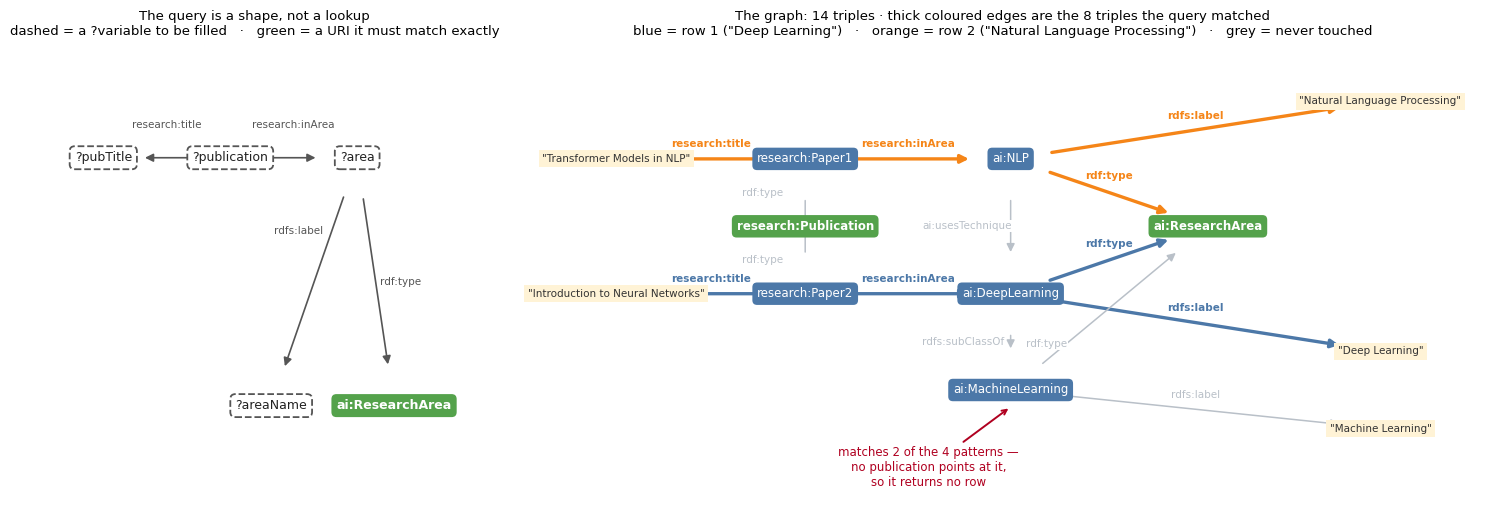

Triples in research_g        : 14
Triples matched by the query : 8  (2 rows x 4 patterns)
Triples never touched        : 6

Result rows returned:
  row 1: Deep Learning  <-  Introduction to Neural Networks
  row 2: Natural Language Processing  <-  Transformer Models in NLP

Research areas declared in the graph : ['ai:DeepLearning', 'ai:MachineLearning', 'ai:NLP']
Research areas in the query result   : ['ai:DeepLearning', 'ai:NLP']
ai:MachineLearning is declared, labelled, and has a subclass — and still returns no row.


In [13]:
# 📊 FIGURE — what a SPARQL query actually does: it matches a SHAPE against the graph.
# WHAT: left = the four triple patterns of `complex_query` above, drawn as a template
#       graph (dashed boxes are the ?variables). Right = all 14 triples of `research_g`,
#       drawn, with every edge the query matched coloured by which result row it belongs
#       to. The highlight is not hand-written: we re-run the query and colour exactly the
#       triples its bindings name.
# WHY: the printout above lists two rows and gives no hint why there is no third.
#      The picture shows the missing area sitting in the graph, unmatched.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from rdflib import Literal

ROW_COLOURS = ["#4C78A8", "#F58518"]      # one colour per result row
GREY = "#B9C0C8"                          # triples the query never touched


def qname(term):
    """URI -> readable prefix:name; a literal stays as its own text."""
    if isinstance(term, Literal):
        return str(term)
    try:
        return research_g.qname(term)
    except Exception:
        return str(term)


def box(ax, xy, text, *, fc, tc="white", dashed=False, literal=False, fs=8.5, bold=False):
    ax.text(xy[0], xy[1], text, ha="center", va="center", fontsize=fs, zorder=4,
            color=tc, fontweight="bold" if bold else "normal",
            bbox=dict(boxstyle="square,pad=0.34" if literal else "round,pad=0.40",
                      fc=fc, ec="#555" if dashed else "none",
                      ls="--" if dashed else "-", lw=1.3 if dashed else 0))


def edge(ax, p1, p2, label, colour, *, lw=1.2, t=0.5, dx=0.0, dy=0.30, fs=7.5, bold=False):
    """Draw one triple as an arrow, with its predicate placed at fraction t along it."""
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=12,
                                 color=colour, lw=lw, shrinkA=30, shrinkB=30, zorder=1))
    ax.text(p1[0] + t * (p2[0] - p1[0]) + dx, p1[1] + t * (p2[1] - p1[1]) + dy,
            label, fontsize=fs, ha="center", va="center", color=colour, zorder=3,
            fontweight="bold" if bold else "normal",
            bbox=dict(fc="white", ec="none", pad=0.8))


fig, (axQ, axG) = plt.subplots(1, 2, figsize=(15.0, 5.4),
                               gridspec_kw={"width_ratios": [1, 2.15]})

# ---------------- LEFT: the query, drawn as the shape it is ----------------
QP = {"?pubTitle": (-3.1, 1.2), "?publication": (0.0, 1.2), "?area": (3.1, 1.2),
      "?areaName": (1.0, -1.4), "ai:ResearchArea": (4.0, -1.4)}
edge(axQ, QP["?publication"], QP["?pubTitle"], "research:title", "#555", dy=0.34)
edge(axQ, QP["?publication"], QP["?area"], "research:inArea", "#555", dy=0.34)
edge(axQ, QP["?area"], QP["?areaName"], "rdfs:label", "#555", t=0.42, dx=-0.55, dy=0.32)
edge(axQ, QP["?area"], QP["ai:ResearchArea"], "rdf:type", "#555", t=0.5, dx=0.62, dy=0.0)
for name, pos in QP.items():
    if name.startswith("?"):
        box(axQ, pos, name, fc="white", tc="#222", dashed=True, fs=9)
    else:
        box(axQ, pos, name, fc="#54A24B", bold=True, fs=9)
axQ.set_xlim(-5.0, 6.2); axQ.set_ylim(-2.6, 2.4); axQ.set_axis_off()
axQ.set_title("The query is a shape, not a lookup\n"
              "dashed = a ?variable to be filled   ·   green = a URI it must match exactly",
              fontsize=9.5)

# ---------------- RIGHT: the data graph, with the matches coloured ---------
POS = {
    "research:Publication": (-4.4, 0.0),
    "research:Paper1": (-4.4, 1.4), "research:Paper2": (-4.4, -1.4),
    "ai:NLP": (0.6, 1.4), "ai:DeepLearning": (0.6, -1.4),
    "ai:MachineLearning": (0.6, -3.4), "ai:ResearchArea": (5.4, 0.0),
}
LIT = {
    ("research:Paper1", "research:title"): (-9.0, 1.4),
    ("research:Paper2", "research:title"): (-9.0, -1.4),
    ("ai:NLP", "rdfs:label"): (9.6, 2.6),
    ("ai:DeepLearning", "rdfs:label"): (9.6, -2.6),
    ("ai:MachineLearning", "rdfs:label"): (9.6, -4.2),
}
# Per-edge label placement, chosen so no predicate name lands on a box or another arrow.
TWEAK = {("ai:NLP", "rdf:type"): dict(t=0.5, dy=0.34),
         ("ai:DeepLearning", "rdf:type"): dict(t=0.5, dy=0.34),
         ("ai:MachineLearning", "rdf:type"): dict(t=0.18, dy=0.34),
         ("ai:NLP", "ai:usesTechnique"): dict(t=0.5, dx=-1.05, dy=0.0),
         ("ai:DeepLearning", "rdfs:subClassOf"): dict(t=0.5, dx=-1.15, dy=0.0),
         ("research:Paper1", "rdf:type"): dict(t=0.5, dx=-1.05, dy=0.0),
         ("research:Paper2", "rdf:type"): dict(t=0.5, dx=-1.05, dy=0.0)}

rows = list(research_g.query(complex_query))
matched = {}                        # (subject qname, predicate qname) -> result-row index
for i, row in enumerate(rows):
    a, p = qname(row.area), qname(row.publication)
    for key in ((p, "research:inArea"), (p, "research:title"),
                (a, "rdf:type"), (a, "rdfs:label")):
        matched[key] = i

for s, pred, o in sorted(research_g, key=lambda t: (str(t[0]), str(t[1]))):
    ss, ps, os_ = qname(s), qname(pred), qname(o)
    p1 = POS.get(ss)
    p2 = POS.get(os_) if not isinstance(o, Literal) else LIT.get((ss, ps))
    if p1 is None or p2 is None:
        continue
    idx = matched.get((ss, ps))
    col = ROW_COLOURS[idx] if idx is not None else GREY
    edge(axG, p1, p2, ps, col, lw=2.4 if idx is not None else 1.1,
         bold=idx is not None, **TWEAK.get((ss, ps), {}))
    if isinstance(o, Literal):
        box(axG, p2, f'"{os_}"', fc="#FFF3D6", tc="#333", literal=True, fs=7.5)

for name, pos in POS.items():
    is_class = name in ("ai:ResearchArea", "research:Publication")
    box(axG, pos, name, fc="#54A24B" if is_class else "#4C78A8", bold=is_class, fs=8.5)

axG.annotate("matches 2 of the 4 patterns —\nno publication points at it,\nso it returns no row",
             xy=(0.6, -3.75), xytext=(-1.4, -5.4), fontsize=8.5, color="#B00020",
             ha="center", arrowprops=dict(arrowstyle="->", color="#B00020", lw=1.4))
axG.set_xlim(-11.6, 12.4); axG.set_ylim(-6.1, 3.8); axG.set_axis_off()
axG.set_title(f"The graph: {len(research_g)} triples · thick coloured edges are the "
              f"{len(matched)} triples the query matched\n"
              f"blue = row 1 (\"{rows[0].areaName}\")   ·   "
              f"orange = row 2 (\"{rows[1].areaName}\")   ·   grey = never touched",
              fontsize=9.5)

plt.tight_layout()
plt.show()

print(f"Triples in research_g        : {len(research_g)}")
print(f"Triples matched by the query : {len(matched)}  ({len(rows)} rows x 4 patterns)")
print(f"Triples never touched        : {len(research_g) - len(matched)}")
print("\nResult rows returned:")
for i, row in enumerate(rows):
    print(f"  row {i + 1}: {row.areaName}  <-  {row.pubTitle}")
areas = sorted(qname(a) for a in research_g.subjects(RDF.type, AI.ResearchArea))
print(f"\nResearch areas declared in the graph : {areas}")
print(f"Research areas in the query result   : {sorted(qname(r.area) for r in rows)}")
print("ai:MachineLearning is declared, labelled, and has a subclass — and still returns no row.")


### 👁️ Read the figure

**Left — a SPARQL query is a drawing of the answer you want.** Four dashed boxes and
one green one, joined by four arrows: that *is* `complex_query`. `?publication` must
have a title and point at something with `research:inArea`; that something must carry
a label and be declared `rdf:type ai:ResearchArea`. Nothing else is asked.

**Right — the engine slides that shape over the graph and colours whatever fits.**
Two placements fit, so two rows came back, and the eight thick edges are those two
placements: **orange** is the *Natural Language Processing* row, **blue** is the
*Deep Learning* row. Four edges each — exactly the four arrows on the left.

**Six edges stayed grey, and they are the interesting ones.**

- **`ai:MachineLearning` is grey, and it is a fully-formed research area.** It has
  its `rdf:type ai:ResearchArea` edge and its `rdfs:label`. It matches **2 of the 4**
  patterns — and a partial match is not a match, so the result set never mentions it.
  A query that returns two rows out of three areas gives you no signal at all that a
  third area existed.
- **`rdfs:subClassOf` is grey.** The graph does record that Deep Learning is a kind of
  Machine Learning. The query never asks about that edge, and plain `rdflib` performs
  no inference, so nothing travels along it: a paper filed under Deep Learning does
  **not** become a paper about Machine Learning here. Inheritance is a feature you
  switch on (RDFS/OWL entailment) or write yourself as a property path — it is not
  free with the arrow.
- **Both `rdf:type research:Publication` edges are grey too.** The query never checks
  what a `?publication` *is*; it only requires a `title` and an `inArea`. Add any node
  with those two properties — a blog post, a slide deck — and it would appear in these
  results as a publication. The shape you draw is the whole specification.

**What this proves — and why it is Discuss question 1.** An empty or short SPARQL
result is not a statement about the world; it is a statement about your pattern. The
grey `ai:MachineLearning` box is the open-world assumption made visible: the query
cannot tell you whether that area has no publications, or whether nobody has recorded
them yet, and it does not warn you that the question came up.

## Part 5: Saving and Loading RDF Graphs

RDF graphs can be saved to files and loaded later for reuse.


In [14]:
# Save the graph to a file
output_file = "university_knowledge_graph.ttl"
g.serialize(destination=output_file, format='turtle')
print(f"✅ Saved knowledge graph to {output_file}")

# Load the graph back
loaded_g = Graph()
loaded_g.parse(output_file, format='turtle')
print(f"✅ Loaded knowledge graph from {output_file}")
print(f" Loaded {len(loaded_g)} triples")


✅ Saved knowledge graph to university_knowledge_graph.ttl
✅ Loaded knowledge graph from university_knowledge_graph.ttl
 Loaded 15 triples


## 💬 Discuss

You built a 15-triple university graph, queried it three ways, then built a
second graph for research areas. Argue:

1. Query 3 asked for courses with prerequisites and returned exactly one row:
   *Python for AI requires Introduction to AI*. AIAT 111 has no prerequisite, so
   it does not appear. **Does that empty result mean "AIAT 111 has no
   prerequisite" or "nobody has recorded one yet"?** Your graph cannot tell you.
   Where does that ambiguity become dangerous — try a medical or a legal example.
2. Google authored its Knowledge Graph centrally; Wikidata lets anyone edit.
   For a Saudi ministry building a knowledge graph of its own services and
   regulations, **which governance model would you argue for**, and what specific
   damage does the model you rejected risk?
3. In 2026 the usual competitor to a knowledge graph is a vector store: embed the
   documents, retrieve by similarity, let a language model read them. A graph
   answers *"which courses require AIAT 111"* exactly; a vector store answers
   *"what is this document about"* fuzzily. Pick a real question a Saudi
   university would ask, and argue which one you would build — and what you would
   lose either way.


## Summary

### Key Concepts Learned:

1. **RDF (Resource Description Framework)**
   - Represents knowledge as triples (Subject-Predicate-Object)
   - Uses namespaces to avoid naming conflicts
   - Can be serialized in multiple formats (XML, Turtle, JSON-LD)

2. **SPARQL Query Language**
   - Standard query language for RDF graphs
   - Similar to SQL but works with graph data
   - Supports SELECT, ASK, CONSTRUCT, and DESCRIBE queries

3. **Knowledge Graphs**
   - Graph-based representation of knowledge
   - Useful for representing complex relationships
   - Enables powerful querying and reasoning

### Real-World Applications:

- **Semantic Web**: RDF is the foundation of the Semantic Web
- **Knowledge Bases**: Wikipedia data, DBpedia, Wikidata use RDF
- **Enterprise Knowledge Management**: Organizing organizational knowledge
- **AI Systems**: Representing domain knowledge for expert systems

### Next Steps:

1. Practice writing SPARQL queries for different scenarios
2. Explore public RDF datasets (DBpedia, Wikidata)
3. Learn about RDF Schema (RDFS) and OWL ontologies
4. Integrate RDF/SPARQL into AI applications

---

**Reference:** This notebook covers the practical requirement from Course 01, Unit 2: "Working with RDF and SPARQL for knowledge graph queries"

## ⚠️ Where this breaks

Triples are wonderfully flexible, and every one of these limits is the cost of
that flexibility.

- **RDF has no built-in schema, so nothing stops nonsense.** Assert that a course
  teaches an instructor, or that credit hours equal `"blue"`, and `rdflib` will
  store it without complaint. Constraints need a separate layer (RDFS, OWL,
  SHACL), which is a second language to learn and maintain.
- **The open-world assumption bites.** In a relational database, a row that is not
  there means the fact is false. In RDF, a missing triple means *unknown*. Our
  prerequisite query returned nothing for AIAT 111 — and "no prerequisite" and
  "not yet recorded" are indistinguishable in the output. Any system that treats
  an empty SPARQL result as "no" is making an unsound inference.
- **Identity is your problem, not the format's.** `uni:AIAT111` and a triple from
  another department's graph naming the same course differently are two entities
  as far as the store is concerned. Entity resolution — deciding that two URIs
  mean the same thing — is most of the work in any real deployment, and it is not
  what this notebook showed you.
- **SPARQL joins get expensive fast.** Each additional triple pattern is a join.
  Our queries ran over 15 triples; the same query shape over a billion-triple
  store needs indexing strategy, query planning and often a rewrite. "It worked in
  the notebook" transfers badly here.
- **Serialisation format is not the hard part.** We printed RDF/XML and Turtle,
  and they are trivially interconvertible. Choosing a vocabulary — should this be
  `foaf:name`, `rdfs:label`, or something local? — is the decision that determines
  whether anyone else can use your graph, and no serialiser helps with it.
- **When not to use a knowledge graph:** when your data is a fixed set of columns
  that will not change (use a table), when the questions are similarity questions
  rather than relationship questions (use embeddings), or when you have no budget
  for the ongoing curation that keeps a graph true. An out-of-date knowledge graph
  is worse than none, because it answers confidently.


## 🔭 State of the field (2026)

Knowledge graphs did not lose to language models; they were absorbed by them. The 2024–2026 pattern is
**graph-indexed retrieval**: extract entities and relations from a document collection, then answer a
question by traversing that structure instead of retrieving loose text chunks. GraphRAG showed this is
what makes corpus-level questions ("what themes run across all of these documents?") answerable at
all, because no single chunk contains the answer (Edge et al., 2024); LightRAG then made the index
cheap to build and update incrementally, which is what a classroom-scale corpus can actually afford
(Guo et al., 2024). The triples, namespaces and joins you wrote by hand above are precisely what those
systems construct automatically — and their failure modes are the ones already listed in "Where this
breaks": an extracted graph inherits every ambiguity, every duplicate entity and every missing schema
constraint of the text it came from.

That is the argument for learning RDF and SPARQL first. Writing triples by hand is what lets you
inspect, query and repair such an index instead of trusting it, and the query patterns are identical
whichever end of the pipeline built the graph.

*Orientation only — the assessed content of this lesson is everything above this box.*

## 📚 References

1. Berners-Lee, T., Hendler, J., & Lassila, O. (2001). *The Semantic Web*. Scientific American, 284(5), 34–43.
2. Hogan, A., Blomqvist, E., Cochez, M., et al. (2021). *Knowledge Graphs*. ACM Computing Surveys, 54(4). <https://arxiv.org/abs/2003.02320>
3. Edge, D., Trinh, H., Cheng, N., et al. (2024). *From Local to Global: A Graph RAG Approach to Query-Focused Summarization*. arXiv. <https://arxiv.org/abs/2404.16130>
4. Guo, Z., Xia, L., Yu, Y., et al. (2024). *LightRAG: Simple and Fast Retrieval-Augmented Generation*. arXiv. <https://arxiv.org/abs/2410.05779>